# Topstep 50K Combine Simulation

Test walk-forward validated model against Topstep 50K combine rules.

## Topstep 50K Rules:
- Starting Balance: $50,000
- Profit Target: $3,000
- Daily Loss Limit: $2,000
- Trailing Max Drawdown: $2,500 (from high water mark)
- Consistency: No single day > 50% of total profit
- Max Days: 252 (1 trading year)

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Setup paths
project_root = Path().resolve().parent if Path().resolve().name == 'analysis' else Path().resolve()
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Working directory: {project_root}")

Working directory: /Users/eshaanganguly/Documents/projects/algos 3 topstep


In [2]:
# Topstep 50K Rules
TOPSTEP_50K = {
    'starting_balance': 50_000,
    'profit_target': 3_000,
    'daily_loss_limit': 2_000,
    'trailing_drawdown': 2_500,
    'consistency_limit': 0.50,  # No single day > 50% of profit target
    'max_days': 252,
}

print("Topstep 50K Combine Rules:")
print("=" * 50)
for k, v in TOPSTEP_50K.items():
    if isinstance(v, float) and v < 1:
        print(f"  {k}: {v:.0%}")
    elif isinstance(v, (int, float)) and v >= 1000:
        print(f"  {k}: ${v:,.0f}")
    else:
        print(f"  {k}: {v}")

Topstep 50K Combine Rules:
  starting_balance: $50,000
  profit_target: $3,000
  daily_loss_limit: $2,000
  trailing_drawdown: $2,500
  consistency_limit: 50%
  max_days: 252


## 1. Load Walk-Forward Trades

In [3]:
# Load all walk-forward trades
RUN_DIR = Path("runs/mid2022_20251227_043831_90e86589")
WF_DIR = RUN_DIR / "walkforward" / "bar_size=1m"

all_trades = []
for window_dir in sorted(WF_DIR.glob("window_*")):
    trades_path = window_dir / "trades.parquet"
    if trades_path.exists():
        df = pd.read_parquet(trades_path)
        # Only keep executed trades
        executed = df[df['executed'] == True].copy()
        if len(executed) > 0:
            executed['window'] = window_dir.name
            all_trades.append(executed)

trades_df = pd.concat(all_trades, ignore_index=True)
trades_df['entry_ts'] = pd.to_datetime(trades_df['entry_ts'])
trades_df['exit_ts'] = pd.to_datetime(trades_df['exit_ts'])
trades_df['date'] = trades_df['entry_ts'].dt.date
trades_df = trades_df.sort_values('entry_ts').reset_index(drop=True)

print(f"Total executed trades: {len(trades_df)}")
print(f"Date range: {trades_df['date'].min()} to {trades_df['date'].max()}")
print(f"\nPnL Summary:")
print(f"  Total PnL: ${trades_df['pnl_usd'].sum():,.2f}")
print(f"  Avg PnL: ${trades_df['pnl_usd'].mean():,.2f}")
print(f"  Win Rate: {(trades_df['pnl_usd'] > 0).mean():.1%}")

Total executed trades: 447
Date range: 2022-12-16 to 2025-08-11

PnL Summary:
  Total PnL: $26,311.09
  Avg PnL: $59.13
  Win Rate: 69.1%


In [4]:
# Daily PnL
daily_pnl = trades_df.groupby('date')['pnl_usd'].sum().reset_index()
daily_pnl.columns = ['date', 'pnl']
daily_pnl = daily_pnl.sort_values('date').reset_index(drop=True)

print(f"Trading days: {len(daily_pnl)}")
print(f"\nDaily PnL Statistics:")
print(f"  Mean: ${daily_pnl['pnl'].mean():,.2f}")
print(f"  Std:  ${daily_pnl['pnl'].std():,.2f}")
print(f"  Min:  ${daily_pnl['pnl'].min():,.2f}")
print(f"  Max:  ${daily_pnl['pnl'].max():,.2f}")
print(f"\nWin days: {(daily_pnl['pnl'] > 0).sum()} / {len(daily_pnl)} ({(daily_pnl['pnl'] > 0).mean():.1%})")

Trading days: 124

Daily PnL Statistics:
  Mean: $212.19
  Std:  $324.59
  Min:  $-556.09
  Max:  $1,157.57

Win days: 95 / 124 (76.6%)


## 2. Topstep Combine Simulator

In [5]:
def simulate_topstep_combine(
    daily_pnl: pd.Series,
    starting_balance: float = 50_000,
    profit_target: float = 3_000,
    daily_loss_limit: float = 2_000,
    trailing_drawdown: float = 2_500,
    consistency_limit: float = 0.50,
    max_days: int = 252,
) -> dict:
    """
    Simulate a single Topstep combine attempt.
    
    Returns:
        dict with 'passed', 'fail_reason', 'days', 'final_balance', 'max_drawdown'
    """
    equity = starting_balance
    high_water_mark = starting_balance
    max_drawdown = 0
    cumulative_profit = 0
    daily_profits = []
    
    for day_idx, day_pnl in enumerate(daily_pnl):
        if day_idx >= max_days:
            return {
                'passed': False,
                'fail_reason': 'max_days',
                'days': day_idx,
                'final_balance': equity,
                'max_drawdown': max_drawdown,
            }
        
        # Check daily loss limit BEFORE trade
        if day_pnl < -daily_loss_limit:
            # Cap the loss at daily limit (in practice, you'd stop trading)
            day_pnl = -daily_loss_limit
        
        # Apply PnL
        equity += day_pnl
        cumulative_profit += day_pnl
        if day_pnl > 0:
            daily_profits.append(day_pnl)
        
        # Update high water mark
        if equity > high_water_mark:
            high_water_mark = equity
        
        # Check trailing drawdown
        current_dd = high_water_mark - equity
        max_drawdown = max(max_drawdown, current_dd)
        
        if current_dd >= trailing_drawdown:
            return {
                'passed': False,
                'fail_reason': 'trailing_drawdown',
                'days': day_idx + 1,
                'final_balance': equity,
                'max_drawdown': max_drawdown,
            }
        
        # Check daily loss limit breach (account level)
        if day_pnl <= -daily_loss_limit:
            return {
                'passed': False,
                'fail_reason': 'daily_loss',
                'days': day_idx + 1,
                'final_balance': equity,
                'max_drawdown': max_drawdown,
            }
        
        # Check if profit target reached
        if cumulative_profit >= profit_target:
            # Check consistency rule
            if daily_profits:
                max_single_day = max(daily_profits)
                if max_single_day > cumulative_profit * consistency_limit:
                    # One day was too big - need more consistent profits
                    continue  # Keep trading to dilute the big day
            
            return {
                'passed': True,
                'fail_reason': None,
                'days': day_idx + 1,
                'final_balance': equity,
                'max_drawdown': max_drawdown,
            }
    
    # Ran out of days
    return {
        'passed': False,
        'fail_reason': 'max_days',
        'days': max_days,
        'final_balance': equity,
        'max_drawdown': max_drawdown,
    }

print("Topstep combine simulator ready.")

Topstep combine simulator ready.


## 3. Monte Carlo Simulation

In [6]:
def monte_carlo_combine(
    daily_pnl_values: np.ndarray,
    n_simulations: int = 10_000,
    seed: int = 42,
    **topstep_rules
) -> dict:
    """
    Run Monte Carlo simulation of combine attempts.
    
    Each simulation randomly samples (with replacement) from historical daily PnLs.
    """
    np.random.seed(seed)
    
    max_days = topstep_rules.get('max_days', 252)
    
    results = []
    for _ in range(n_simulations):
        # Random sample of daily PnLs
        simulated_days = np.random.choice(daily_pnl_values, size=max_days, replace=True)
        result = simulate_topstep_combine(simulated_days, **topstep_rules)
        results.append(result)
    
    # Aggregate results
    passed = [r for r in results if r['passed']]
    failed = [r for r in results if not r['passed']]
    
    fail_reasons = {}
    for r in failed:
        reason = r['fail_reason']
        fail_reasons[reason] = fail_reasons.get(reason, 0) + 1
    
    pass_rate = len(passed) / n_simulations
    
    days_to_pass = [r['days'] for r in passed] if passed else []
    max_drawdowns = [r['max_drawdown'] for r in results]
    
    return {
        'n_simulations': n_simulations,
        'pass_rate': pass_rate,
        'pass_count': len(passed),
        'fail_count': len(failed),
        'fail_reasons': fail_reasons,
        'days_to_pass': {
            'mean': np.mean(days_to_pass) if days_to_pass else None,
            'median': np.median(days_to_pass) if days_to_pass else None,
            'p25': np.percentile(days_to_pass, 25) if days_to_pass else None,
            'p75': np.percentile(days_to_pass, 75) if days_to_pass else None,
        },
        'max_drawdown': {
            'mean': np.mean(max_drawdowns),
            'median': np.median(max_drawdowns),
            'p95': np.percentile(max_drawdowns, 95),
        },
    }

print("Monte Carlo simulator ready.")

Monte Carlo simulator ready.


In [7]:
# Run Monte Carlo simulation
print("Running Monte Carlo simulation (10,000 combine attempts)...")
print()

mc_results = monte_carlo_combine(
    daily_pnl['pnl'].values,
    n_simulations=10_000,
    seed=42,
    **TOPSTEP_50K
)

print("=" * 60)
print("TOPSTEP 50K COMBINE MONTE CARLO RESULTS")
print("=" * 60)
print()
print(f"Simulations: {mc_results['n_simulations']:,}")
print()
print(f"PASS RATE: {mc_results['pass_rate']:.1%}")
print(f"  Passed: {mc_results['pass_count']:,}")
print(f"  Failed: {mc_results['fail_count']:,}")
print()
print("Failure Reasons:")
for reason, count in sorted(mc_results['fail_reasons'].items(), key=lambda x: -x[1]):
    pct = count / mc_results['n_simulations'] * 100
    print(f"  {reason}: {count:,} ({pct:.1f}%)")
print()
if mc_results['pass_rate'] > 0:
    print("Days to Pass (when successful):")
    dtp = mc_results['days_to_pass']
    print(f"  Mean: {dtp['mean']:.0f} days")
    print(f"  Median: {dtp['median']:.0f} days")
    print(f"  25th-75th: {dtp['p25']:.0f} - {dtp['p75']:.0f} days")
print()
print("Max Drawdown (across all simulations):")
mdd = mc_results['max_drawdown']
print(f"  Mean: ${mdd['mean']:,.0f}")
print(f"  Median: ${mdd['median']:,.0f}")
print(f"  95th percentile: ${mdd['p95']:,.0f}")

Running Monte Carlo simulation (10,000 combine attempts)...

TOPSTEP 50K COMBINE MONTE CARLO RESULTS

Simulations: 10,000

PASS RATE: 100.0%
  Passed: 10,000
  Failed: 0

Failure Reasons:

Days to Pass (when successful):
  Mean: 16 days
  Median: 15 days
  25th-75th: 11 - 19 days

Max Drawdown (across all simulations):
  Mean: $314
  Median: $303
  95th percentile: $801


## 4. Single Sequential Combine Test

In [8]:
# Run the actual historical sequence (not shuffled)
print("=" * 60)
print("SEQUENTIAL COMBINE TEST (Actual Trade Order)")
print("=" * 60)
print()

sequential_result = simulate_topstep_combine(
    daily_pnl['pnl'].values,
    **TOPSTEP_50K
)

if sequential_result['passed']:
    print(f"PASSED in {sequential_result['days']} days!")
else:
    print(f"FAILED: {sequential_result['fail_reason']}")
    print(f"  Days traded: {sequential_result['days']}")

print(f"\nFinal Balance: ${sequential_result['final_balance']:,.2f}")
print(f"Max Drawdown: ${sequential_result['max_drawdown']:,.2f}")
print(f"Profit: ${sequential_result['final_balance'] - TOPSTEP_50K['starting_balance']:,.2f}")

SEQUENTIAL COMBINE TEST (Actual Trade Order)

PASSED in 17 days!

Final Balance: $53,092.12
Max Drawdown: $269.98
Profit: $3,092.12


## 5. Equity Curve Visualization

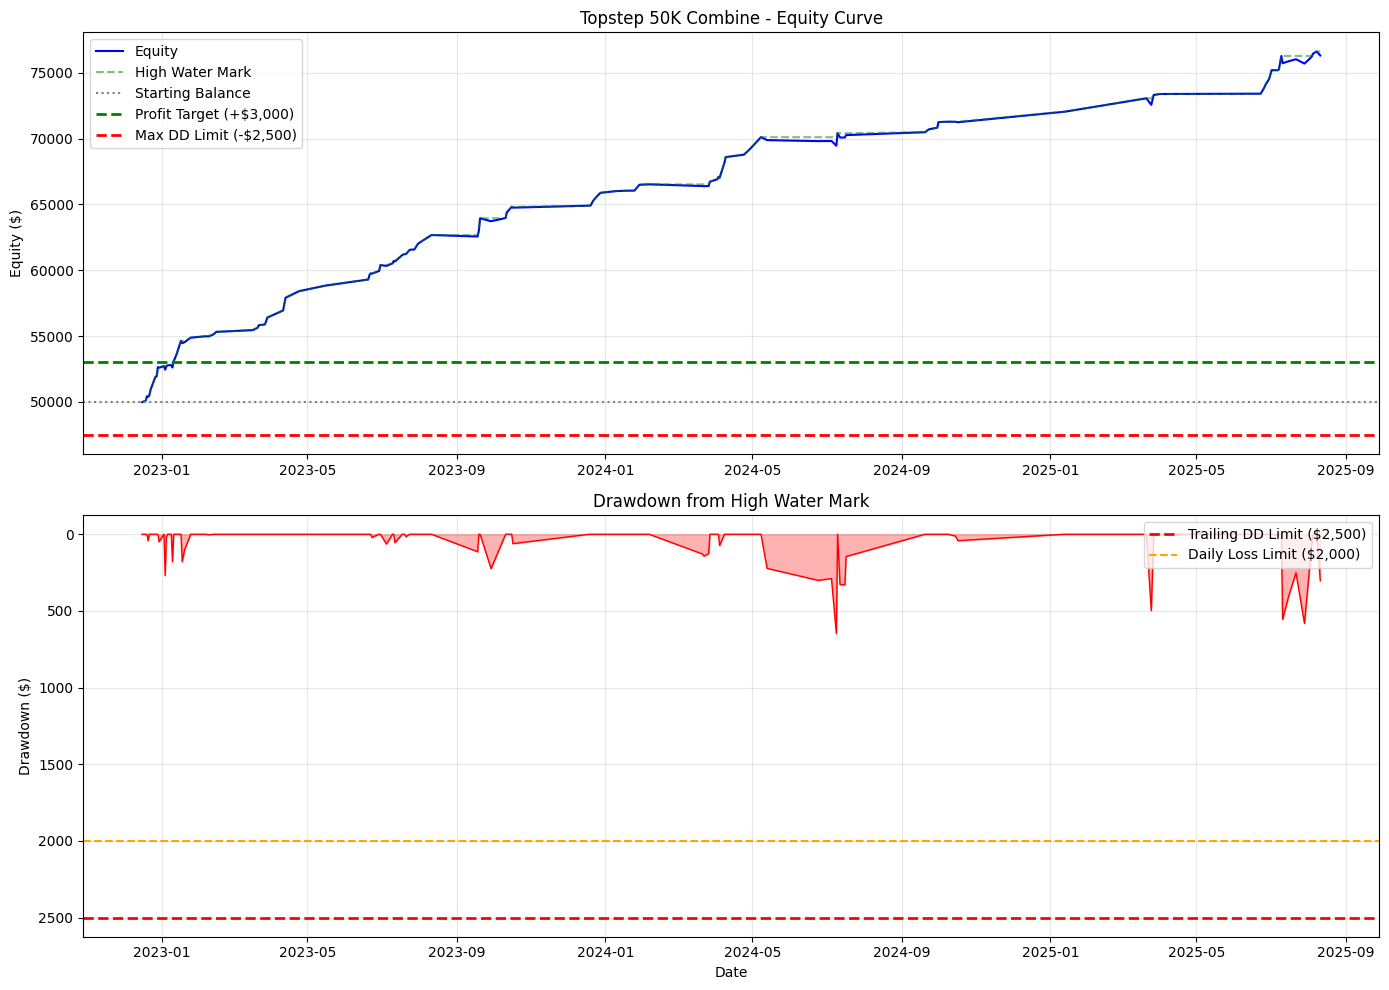


Saved: analysis/topstep_50k_equity_curve.png


In [9]:
# Plot equity curve with Topstep limits
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Compute equity curve
equity = TOPSTEP_50K['starting_balance'] + daily_pnl['pnl'].cumsum()
hwm = equity.cummax()
drawdown = hwm - equity

# Top plot: Equity curve
ax1 = axes[0]
ax1.plot(daily_pnl['date'], equity, 'b-', linewidth=1.5, label='Equity')
ax1.plot(daily_pnl['date'], hwm, 'g--', alpha=0.5, label='High Water Mark')

# Topstep limits
ax1.axhline(TOPSTEP_50K['starting_balance'], color='gray', linestyle=':', label='Starting Balance')
ax1.axhline(TOPSTEP_50K['starting_balance'] + TOPSTEP_50K['profit_target'], 
            color='green', linestyle='--', linewidth=2, label=f"Profit Target (+${TOPSTEP_50K['profit_target']:,})")
ax1.axhline(TOPSTEP_50K['starting_balance'] - TOPSTEP_50K['trailing_drawdown'], 
            color='red', linestyle='--', linewidth=2, label=f"Max DD Limit (-${TOPSTEP_50K['trailing_drawdown']:,})")

ax1.set_ylabel('Equity ($)')
ax1.set_title('Topstep 50K Combine - Equity Curve')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Bottom plot: Drawdown
ax2 = axes[1]
ax2.fill_between(daily_pnl['date'], 0, drawdown, color='red', alpha=0.3)
ax2.plot(daily_pnl['date'], drawdown, 'r-', linewidth=1)
ax2.axhline(TOPSTEP_50K['trailing_drawdown'], color='red', linestyle='--', 
            linewidth=2, label=f"Trailing DD Limit (${TOPSTEP_50K['trailing_drawdown']:,})")
ax2.axhline(TOPSTEP_50K['daily_loss_limit'], color='orange', linestyle='--',
            linewidth=1.5, label=f"Daily Loss Limit (${TOPSTEP_50K['daily_loss_limit']:,})")

ax2.set_ylabel('Drawdown ($)')
ax2.set_xlabel('Date')
ax2.set_title('Drawdown from High Water Mark')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('analysis/topstep_50k_equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved: analysis/topstep_50k_equity_curve.png")

## 6. Summary Report

In [10]:
print("=" * 70)
print("TOPSTEP 50K COMBINE ANALYSIS - FINAL REPORT")
print("=" * 70)
print()

print("DATA SOURCE")
print("-" * 70)
print(f"Model: Walk-forward validated (mid-2022 onwards)")
print(f"Trades: {len(trades_df)} executed trades")
print(f"Trading Days: {len(daily_pnl)}")
print(f"Period: {daily_pnl['date'].min()} to {daily_pnl['date'].max()}")
print()

print("TRADE STATISTICS")
print("-" * 70)
print(f"Total PnL: ${trades_df['pnl_usd'].sum():,.2f}")
print(f"Avg Trade: ${trades_df['pnl_usd'].mean():,.2f}")
print(f"Win Rate: {(trades_df['pnl_usd'] > 0).mean():.1%}")
wins = trades_df[trades_df['pnl_usd'] > 0]['pnl_usd'].sum()
losses = abs(trades_df[trades_df['pnl_usd'] < 0]['pnl_usd'].sum())
pf = wins / losses if losses > 0 else float('inf')
print(f"Profit Factor: {pf:.2f}")
print()

print("DAILY STATISTICS")
print("-" * 70)
print(f"Avg Daily PnL: ${daily_pnl['pnl'].mean():,.2f}")
print(f"Daily PnL Std: ${daily_pnl['pnl'].std():,.2f}")
print(f"Best Day: ${daily_pnl['pnl'].max():,.2f}")
print(f"Worst Day: ${daily_pnl['pnl'].min():,.2f}")
print(f"Win Days: {(daily_pnl['pnl'] > 0).sum()} / {len(daily_pnl)} ({(daily_pnl['pnl'] > 0).mean():.1%})")
print()

print("TOPSTEP 50K COMBINE RESULTS")
print("-" * 70)
print(f"Monte Carlo Pass Rate: {mc_results['pass_rate']:.1%}")
if mc_results['pass_rate'] > 0:
    print(f"Median Days to Pass: {mc_results['days_to_pass']['median']:.0f}")
print(f"Sequential Test: {'PASSED' if sequential_result['passed'] else 'FAILED (' + sequential_result['fail_reason'] + ')'}")
print(f"Max Drawdown (95th pct): ${mc_results['max_drawdown']['p95']:,.0f}")
print()

# Risk assessment
print("RISK ASSESSMENT")
print("-" * 70)
daily_loss_risk = (daily_pnl['pnl'] < -TOPSTEP_50K['daily_loss_limit']).mean()
print(f"Days exceeding daily loss limit: {(daily_pnl['pnl'] < -TOPSTEP_50K['daily_loss_limit']).sum()} ({daily_loss_risk:.1%})")
dd_risk = (drawdown > TOPSTEP_50K['trailing_drawdown']).any()
print(f"Trailing DD limit breached: {'Yes' if dd_risk else 'No'}")
print(f"Max observed drawdown: ${drawdown.max():,.2f}")
print()

# Verdict
print("=" * 70)
if mc_results['pass_rate'] >= 0.5:
    verdict = "READY FOR COMBINE"
elif mc_results['pass_rate'] >= 0.2:
    verdict = "MARGINAL - Proceed with caution"
else:
    verdict = "NOT READY - Needs improvement"
print(f"VERDICT: {verdict}")
print("=" * 70)

TOPSTEP 50K COMBINE ANALYSIS - FINAL REPORT

DATA SOURCE
----------------------------------------------------------------------
Model: Walk-forward validated (mid-2022 onwards)
Trades: 447 executed trades
Trading Days: 124
Period: 2022-12-16 to 2025-08-11

TRADE STATISTICS
----------------------------------------------------------------------
Total PnL: $26,311.09
Avg Trade: $59.13
Win Rate: 69.1%
Profit Factor: 3.01

DAILY STATISTICS
----------------------------------------------------------------------
Avg Daily PnL: $212.19
Daily PnL Std: $324.59
Best Day: $1,157.57
Worst Day: $-556.09
Win Days: 95 / 124 (76.6%)

TOPSTEP 50K COMBINE RESULTS
----------------------------------------------------------------------
Monte Carlo Pass Rate: 100.0%
Median Days to Pass: 15
Sequential Test: PASSED
Max Drawdown (95th pct): $801

RISK ASSESSMENT
----------------------------------------------------------------------
Days exceeding daily loss limit: 0 (0.0%)
Trailing DD limit breached: No
Max obse

In [11]:
# Save results
results_summary = {
    'model': 'walk-forward-mid2022',
    'run_dir': str(RUN_DIR),
    'total_trades': len(trades_df),
    'trading_days': len(daily_pnl),
    'date_range': {
        'start': str(daily_pnl['date'].min()),
        'end': str(daily_pnl['date'].max()),
    },
    'trade_stats': {
        'total_pnl': float(trades_df['pnl_usd'].sum()),
        'avg_trade': float(trades_df['pnl_usd'].mean()),
        'win_rate': float((trades_df['pnl_usd'] > 0).mean()),
        'profit_factor': float(pf),
    },
    'daily_stats': {
        'avg_pnl': float(daily_pnl['pnl'].mean()),
        'std_pnl': float(daily_pnl['pnl'].std()),
        'best_day': float(daily_pnl['pnl'].max()),
        'worst_day': float(daily_pnl['pnl'].min()),
    },
    'topstep_50k': {
        'monte_carlo_pass_rate': mc_results['pass_rate'],
        'sequential_passed': sequential_result['passed'],
        'sequential_result': sequential_result,
        'mc_results': mc_results,
    },
}

with open('analysis/topstep_50k_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2, default=str)

print(f"Results saved to: analysis/topstep_50k_results.json")

Results saved to: analysis/topstep_50k_results.json
